In [1]:
import pandas as pd
import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data
co2 = co2["co2"].resample("MS").mean()
co2 = co2.interpolate()
print(co2.shape, co2.index.min(), co2.index.max())
co2.head()

(526,) 1958-03-01 00:00:00 2001-12-01 00:00:00


1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.529167
1958-07-01    315.625000
Freq: MS, Name: co2, dtype: float64

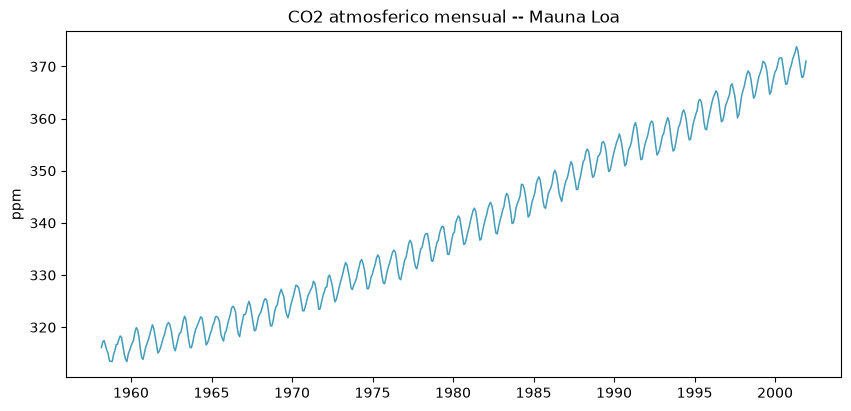

In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(co2.index, co2, color="#449cb9", linewidth=1.1)
ax.set_title("CO2 atmosferico mensual -- Mauna Loa")
ax.set_ylabel("ppm")
plt.savefig("co2-serie-mensual.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
train = co2[:-24]
test = co2[-24:]
print("train:", train.shape, train.index.min(), "a", train.index.max())
print("test :", test.shape, test.index.min(), "a", test.index.max())

train: (502,) 1958-03-01 00:00:00 a 1999-12-01 00:00:00
test : (24,) 2000-01-01 00:00:00 a 2001-12-01 00:00:00


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                  enforce_stationarity=False, enforce_invertibility=False)
resultado = modelo.fit(disp=False)
print(resultado.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  502
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -99.171
Date:                            Wed, 16 Sep 2026   AIC                            208.342
Time:                                    18:50:17   BIC                            229.159
Sample:                                03-01-1958   HQIC                           216.528
                                     - 12-01-1999                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1758      0.125      1.408      0.159      -0.069       0.421
ma.L1         -0.5103      0.112   

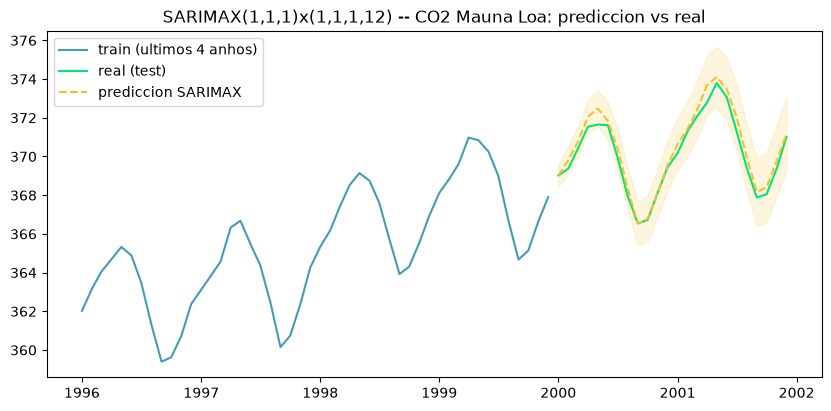

In [5]:
pred = resultado.get_forecast(steps=len(test))
media_pred = pred.predicted_mean
ci = pred.conf_int()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train.index[-48:], train[-48:], color="#449cb9", label="train (ultimos 4 anhos)")
ax.plot(test.index, test, color="#00e676", label="real (test)")
ax.plot(media_pred.index, media_pred, color="#fbbf24", linestyle="--", label="prediccion SARIMAX")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#fbbf24", alpha=0.15)
ax.legend()
ax.set_title("SARIMAX(1,1,1)x(1,1,1,12) -- CO2 Mauna Loa: prediccion vs real")
plt.savefig("co2-sarimax-prediccion.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import numpy as np

rmse = np.sqrt(((media_pred.values - test.values) ** 2).mean())
mae = np.abs(media_pred.values - test.values).mean()
print("RMSE:", round(rmse, 4), "ppm")
print("MAE :", round(mae, 4), "ppm")
print()
print("primeras 5 predicciones vs real:")
comparacion = pd.DataFrame({"prediccion": media_pred.values[:5], "real": test.values[:5]}, index=test.index[:5])
print(comparacion)

RMSE: 0.4237 ppm
MAE : 0.349 ppm

primeras 5 predicciones vs real:
            prediccion     real
2000-01-01  369.011336  369.020
2000-02-01  369.820228  369.375
2000-03-01  370.753781  370.400
2000-04-01  372.047354  371.540
2000-05-01  372.484777  371.650
